In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))
from src.data_loader import load_data
from src.eda_utils import (
    get_categorical_columns, 
 get_numeric_columns, 
 plot_histograms, 
 missing_values_summary, 
 drop_missing_cols, 
 plot_categorical_cols,
 bivariate_scatter_plot,
 multivariate_scatter_plot,
 correlation_matrix,
 correlation_heatmap,
 comparison,
 comparison_plot,
 avg_comparison,
 box_plots,
 overall_loss_ratio,
    plot_categorical_cols,
    plot_histograms,
    province_loss_ratio,
    vehicle_loss_ratio,
    gender_loss_ratio
 )

In [2]:
df = load_data("../data/MachineLearningRating_v3.txt")
df.head()

c:\KAIM_projects\insurance-risk-analytics\src\data_loader.py:5: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep="|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
df.shape

(1000098, 52)

In [4]:
df.dtypes

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                       bool
Citizenship                            str
LegalType                              str
Title                                  str
Language                               str
Bank                                   str
AccountType                            str
MaritalStatus                          str
Gender                                 str
Country                                str
Province                               str
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                            str
RegistrationYear                     int64
make                                   str
Model                                  str
Cylinders  

In [5]:
numeric_cols = get_numeric_columns(df)
df[numeric_cols].describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [6]:
missing_values_summary(df)

In [7]:
df = drop_missing_cols(df)

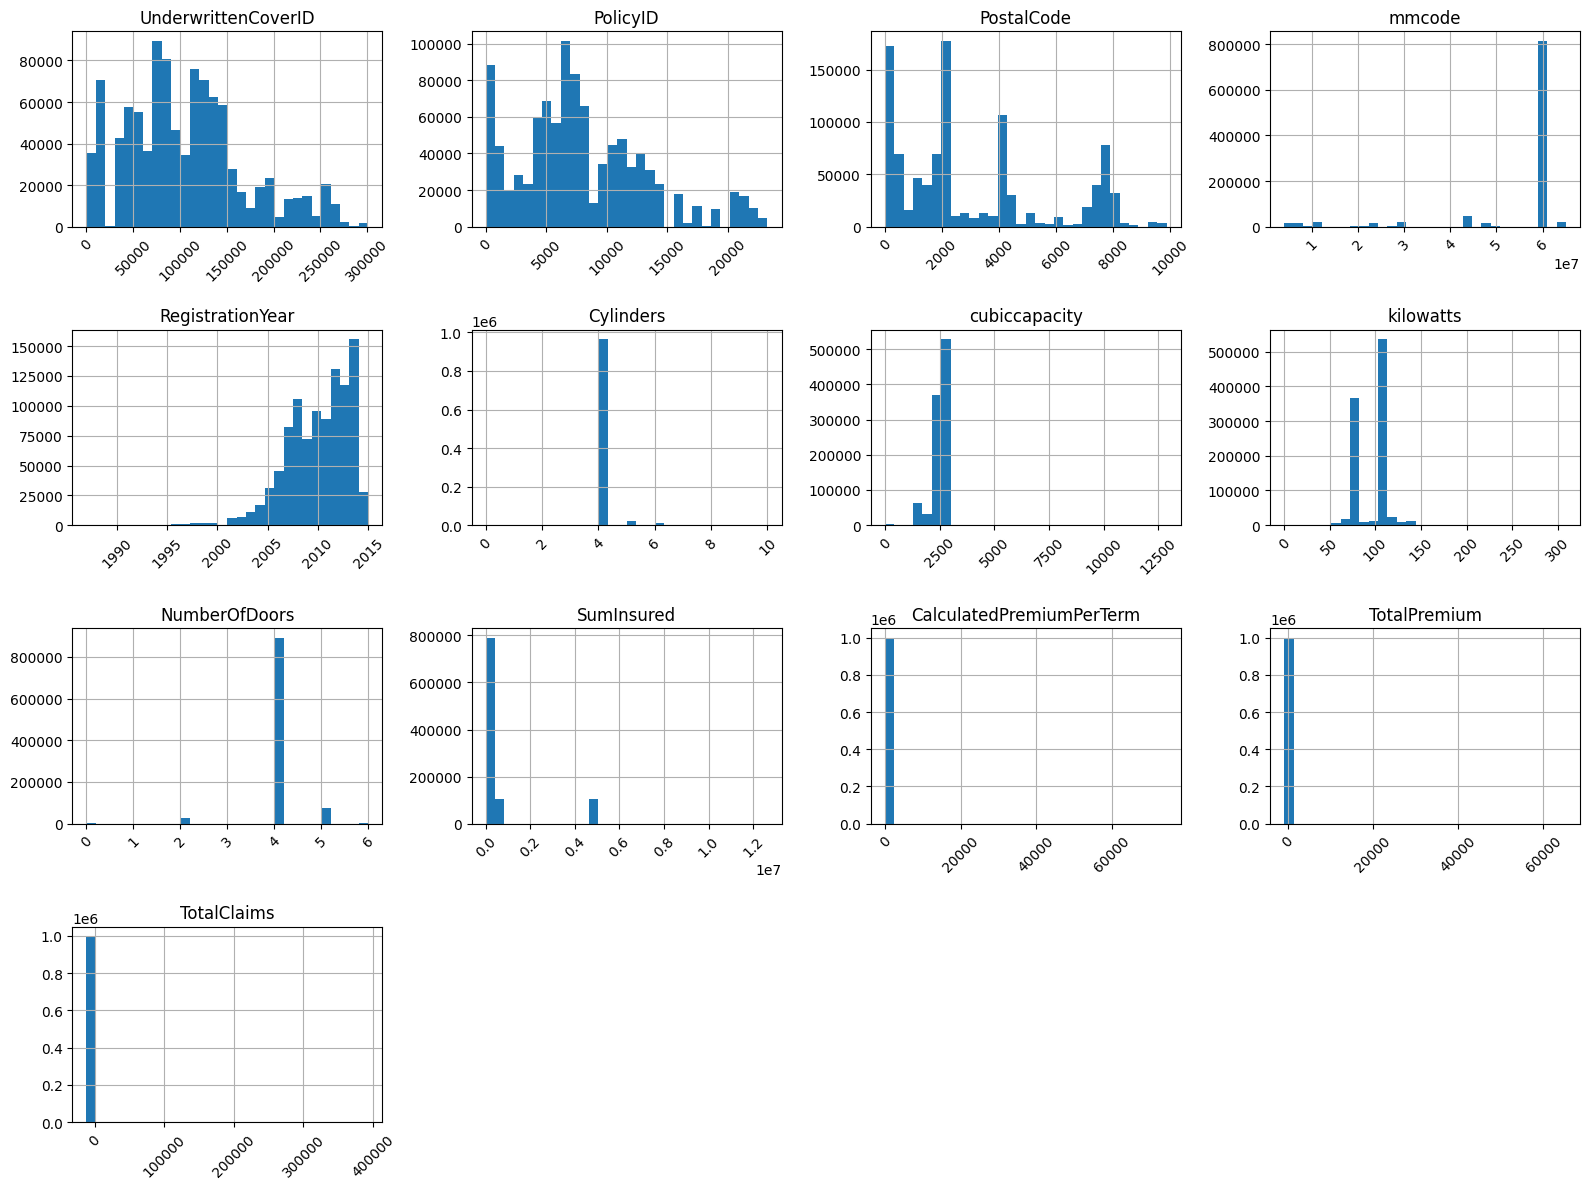

In [8]:
numeric_cols = get_numeric_columns(df)
plot_histograms(df,numeric_cols)

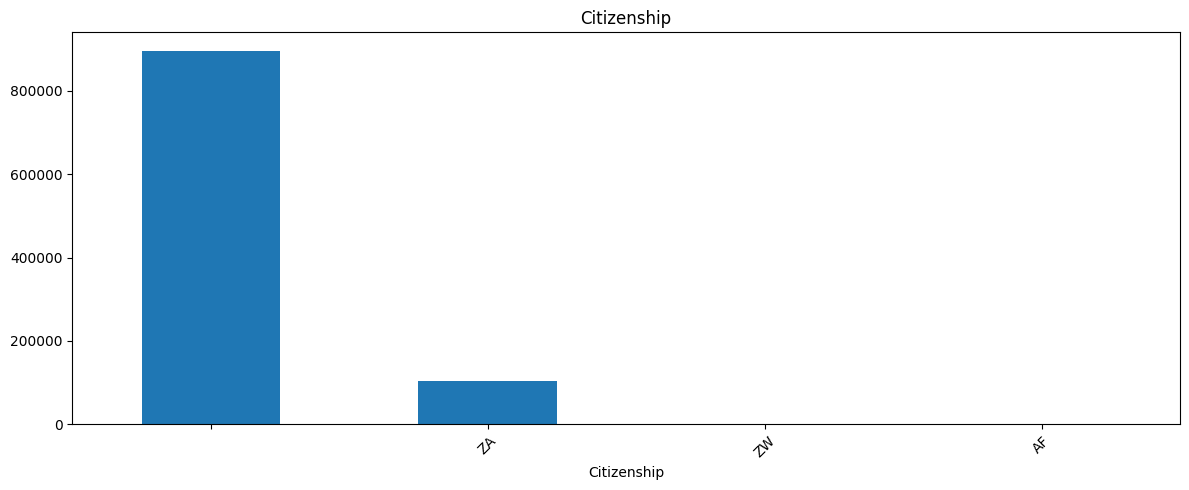

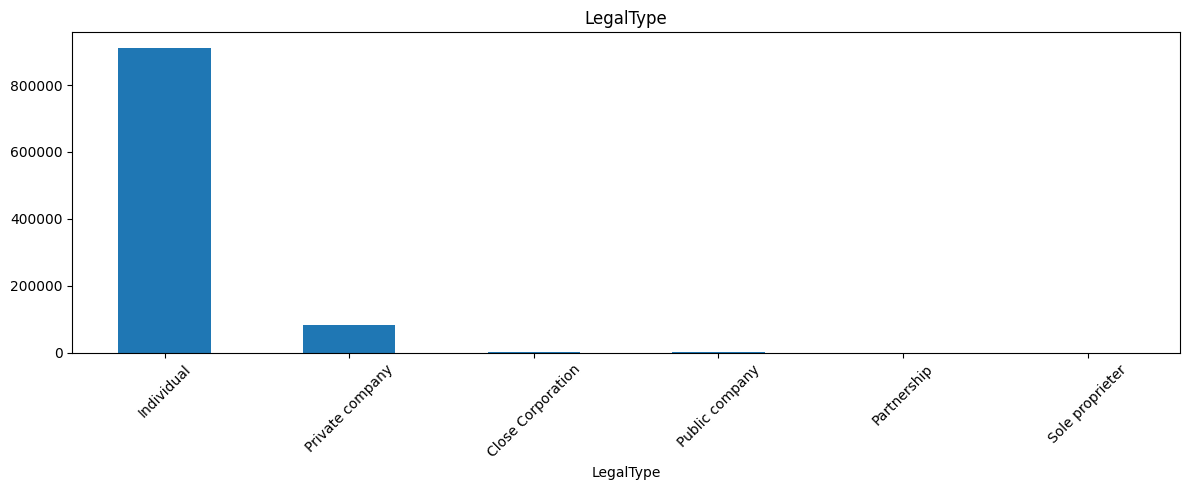

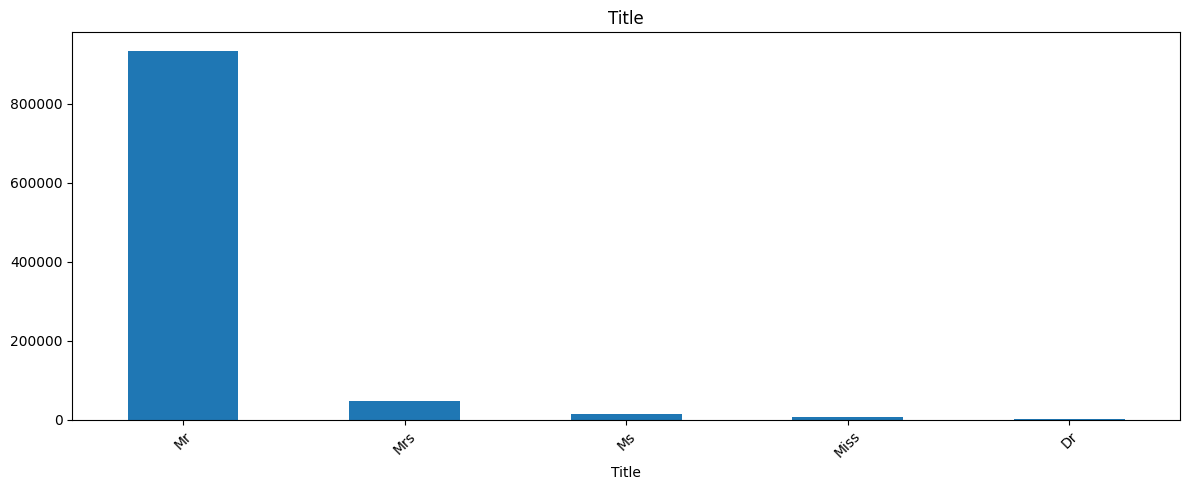

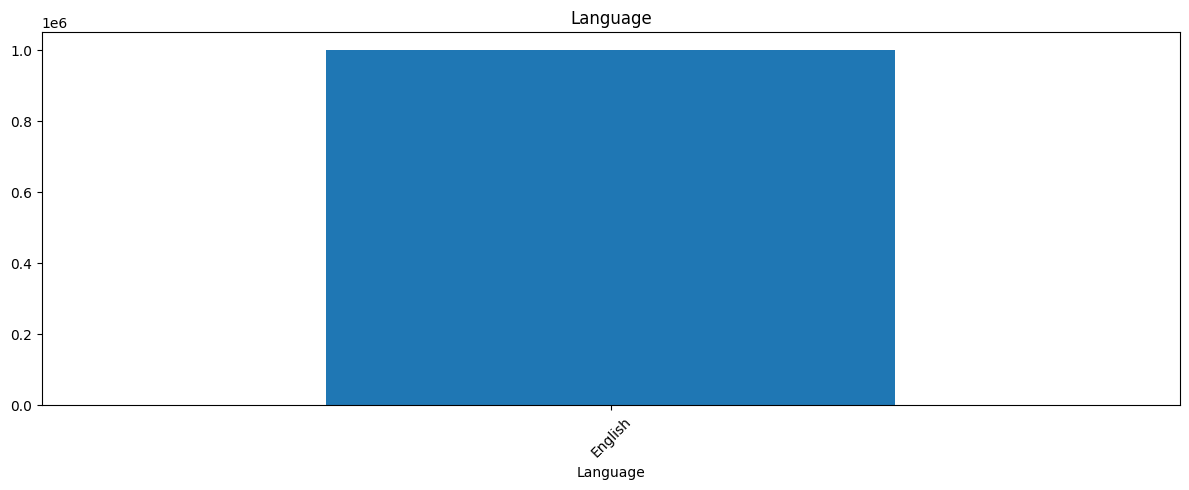

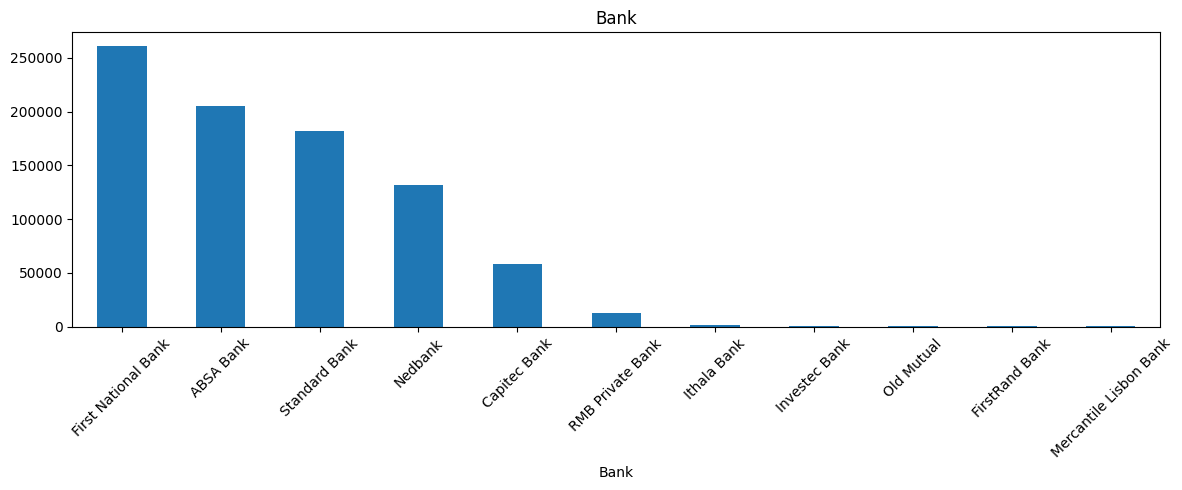

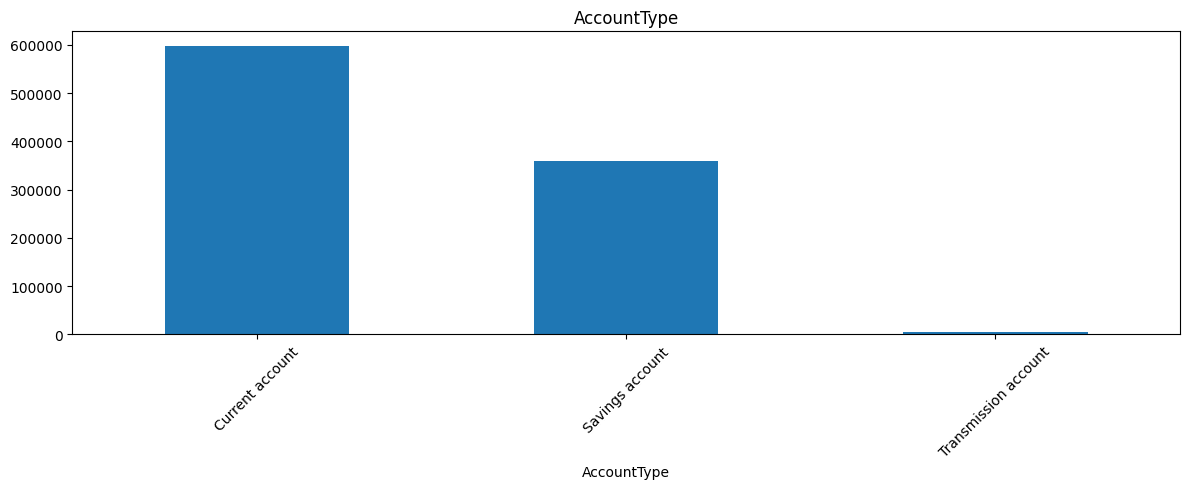

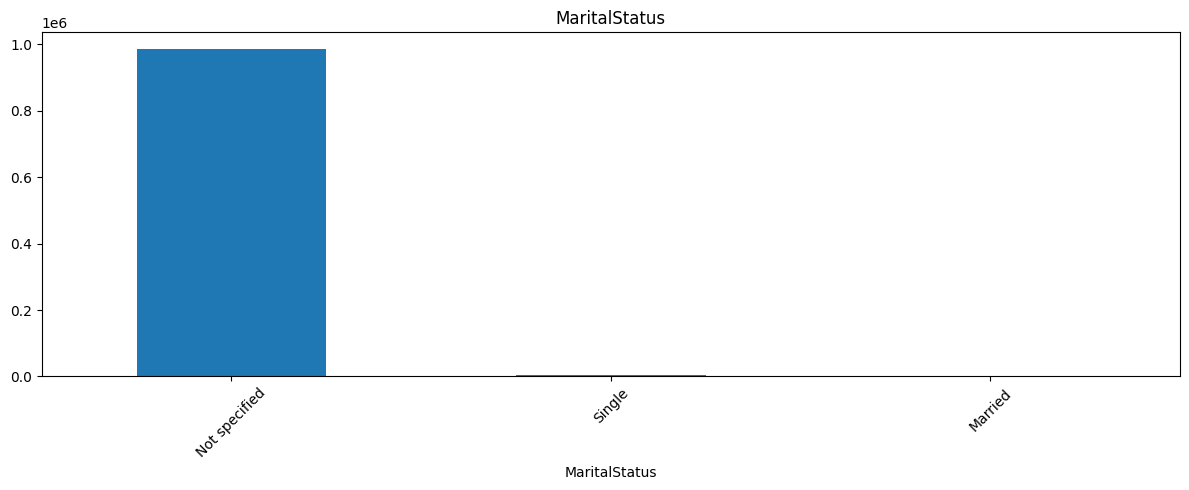

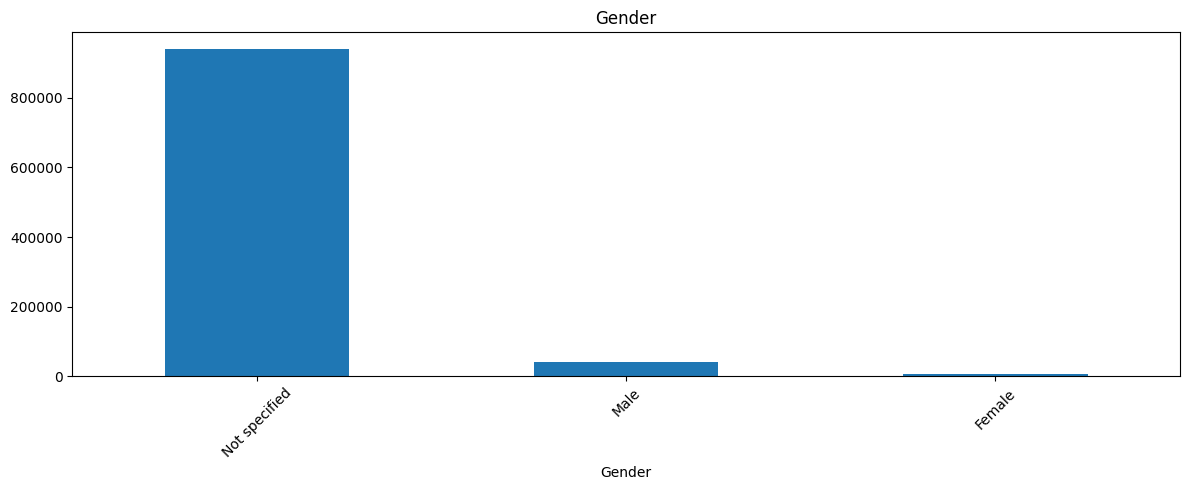

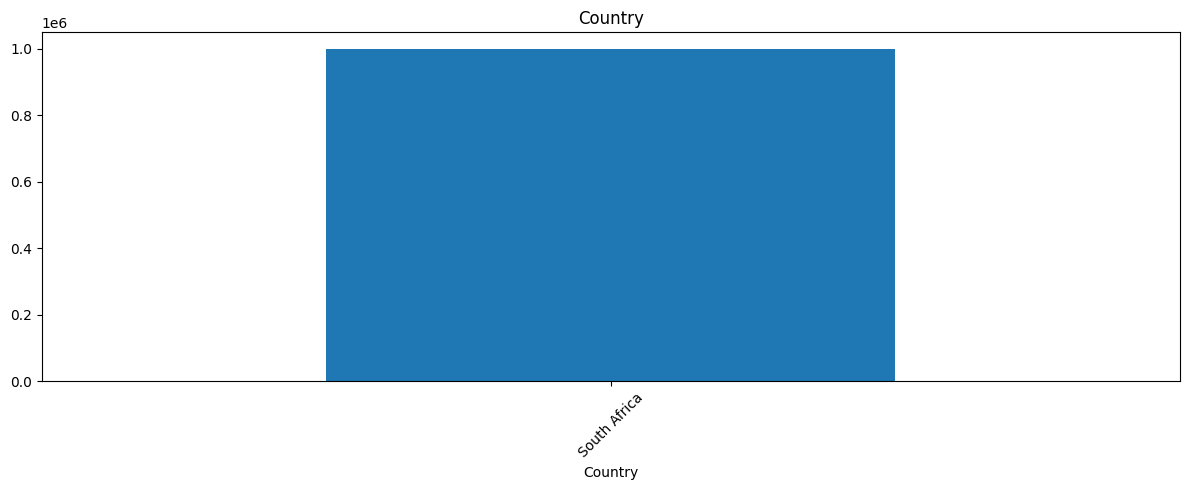

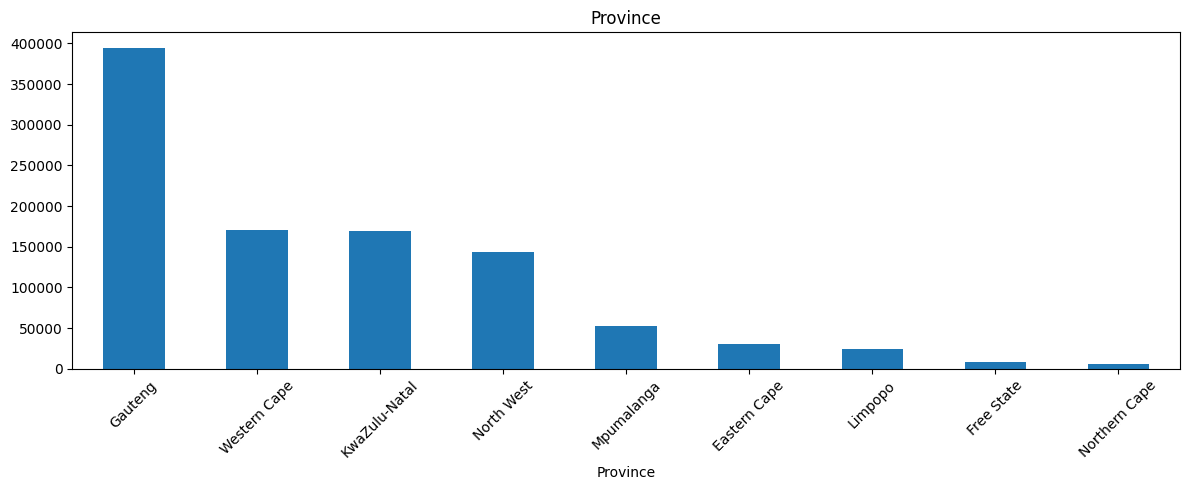

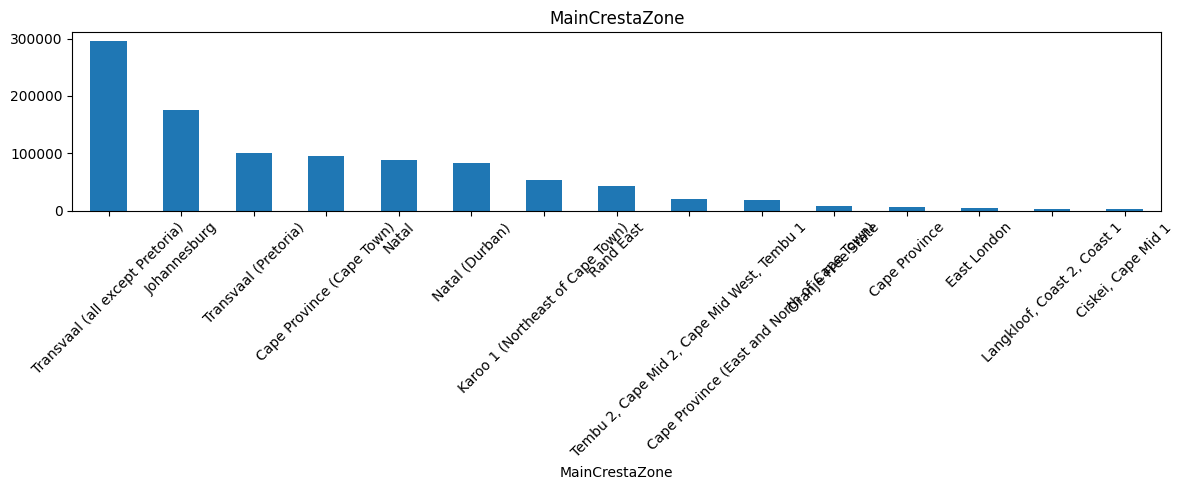

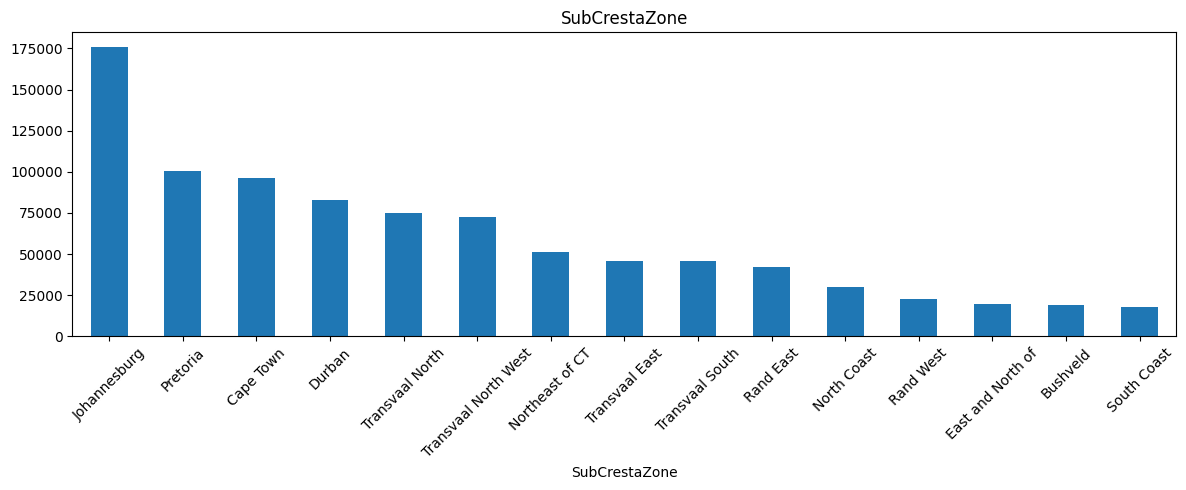

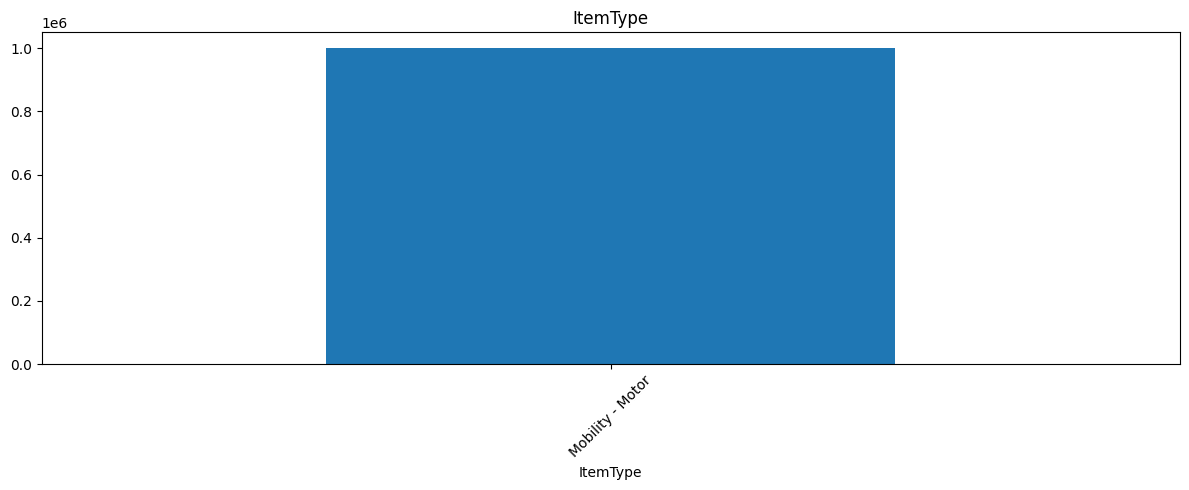

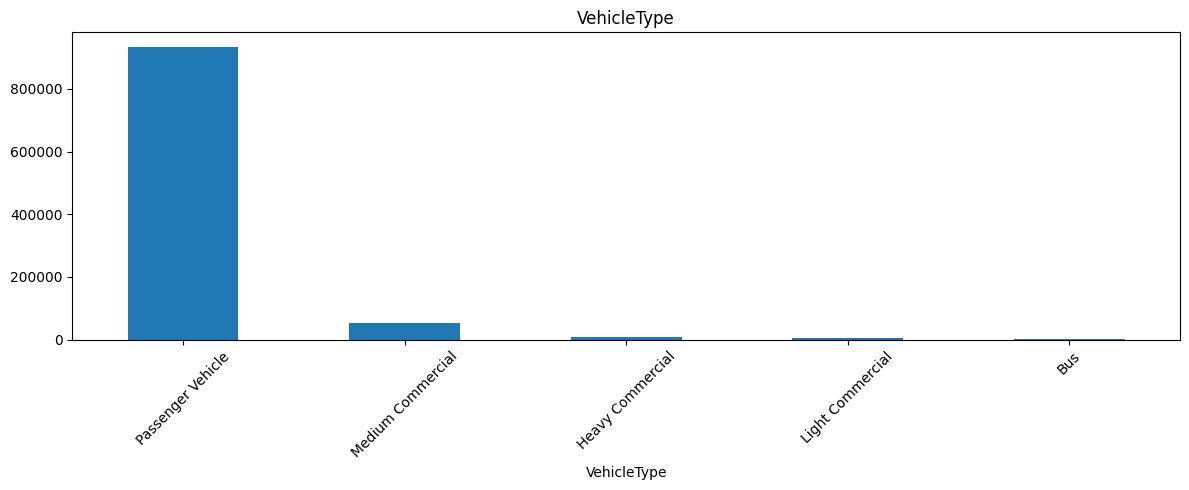

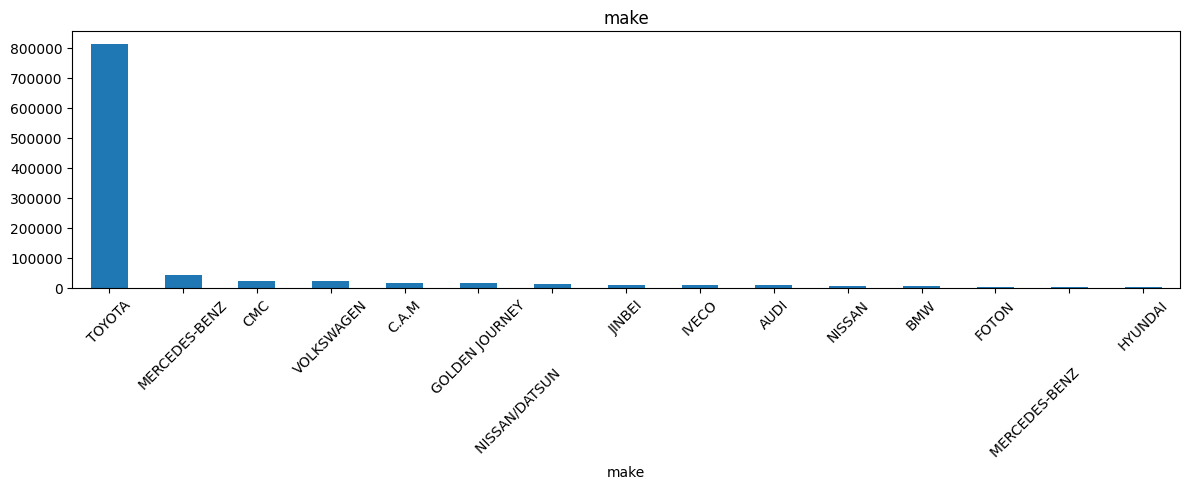

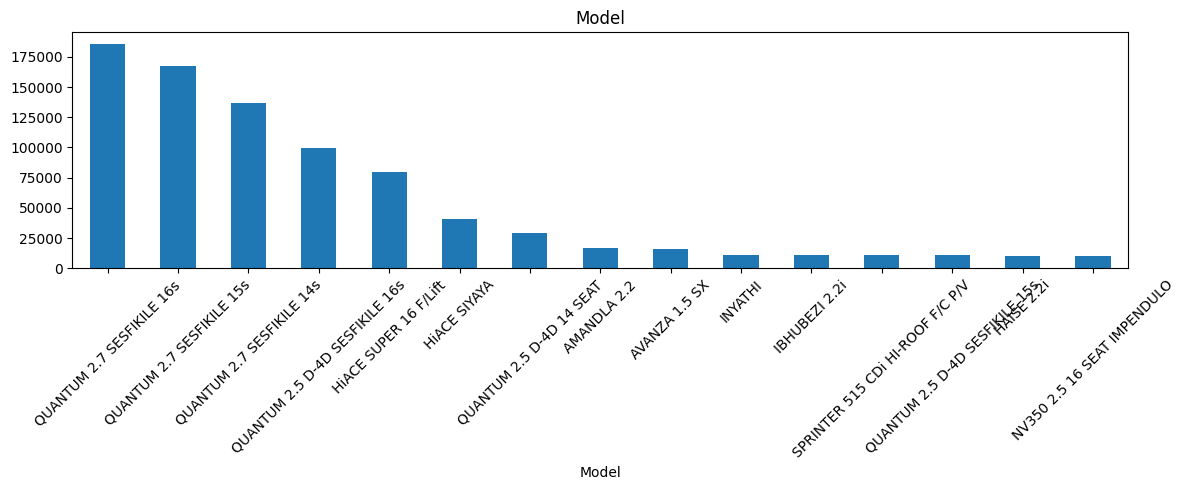

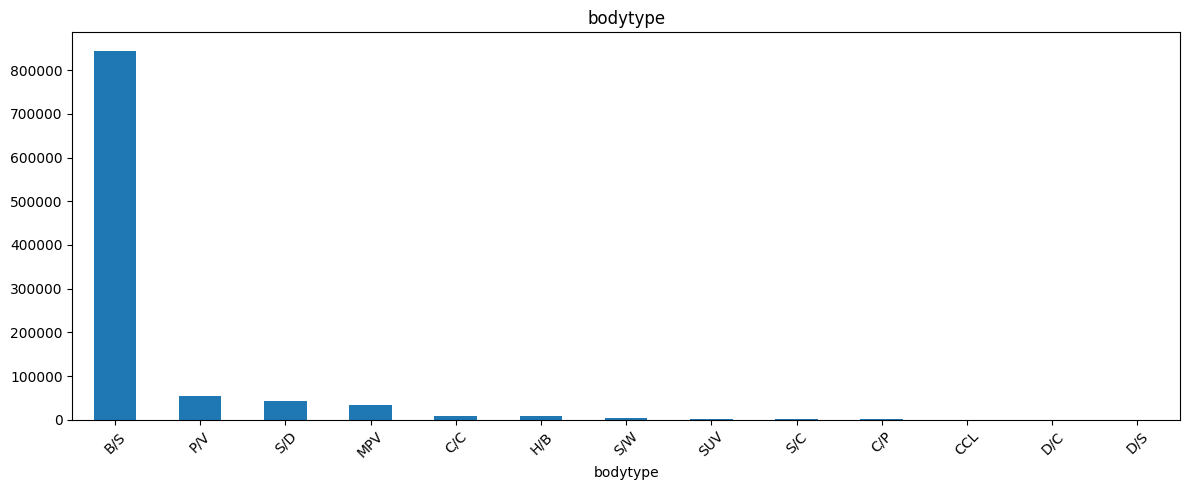

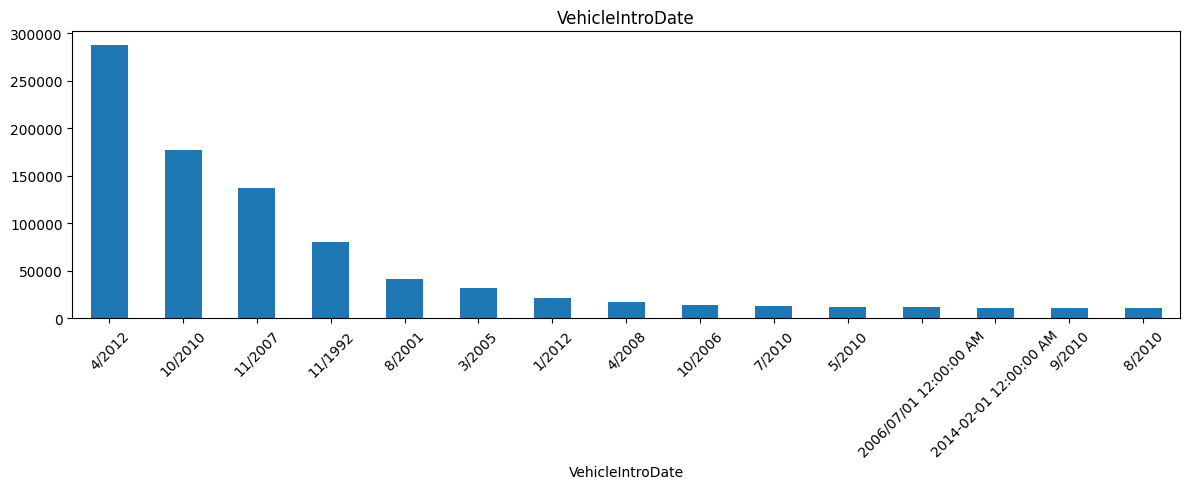

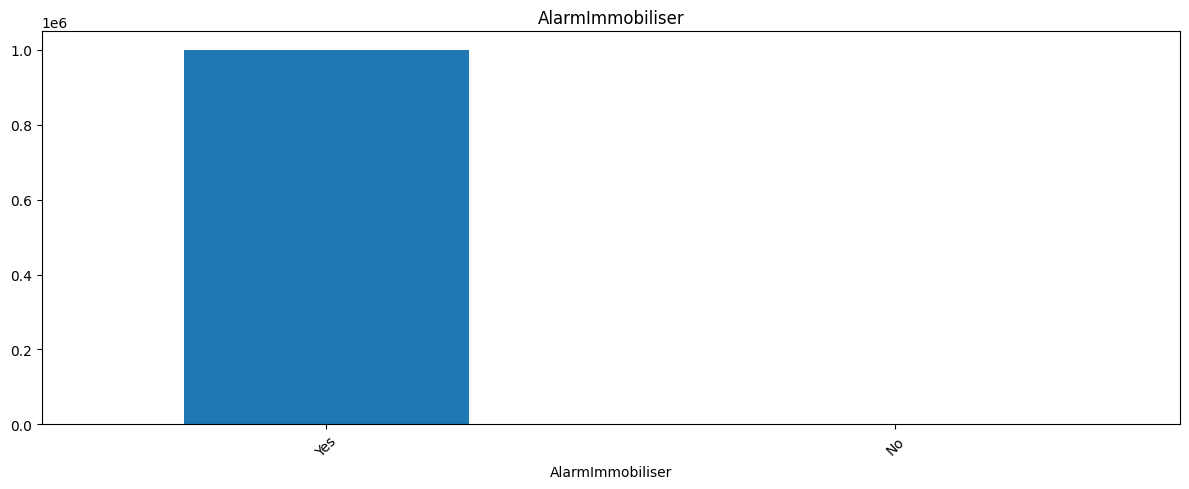

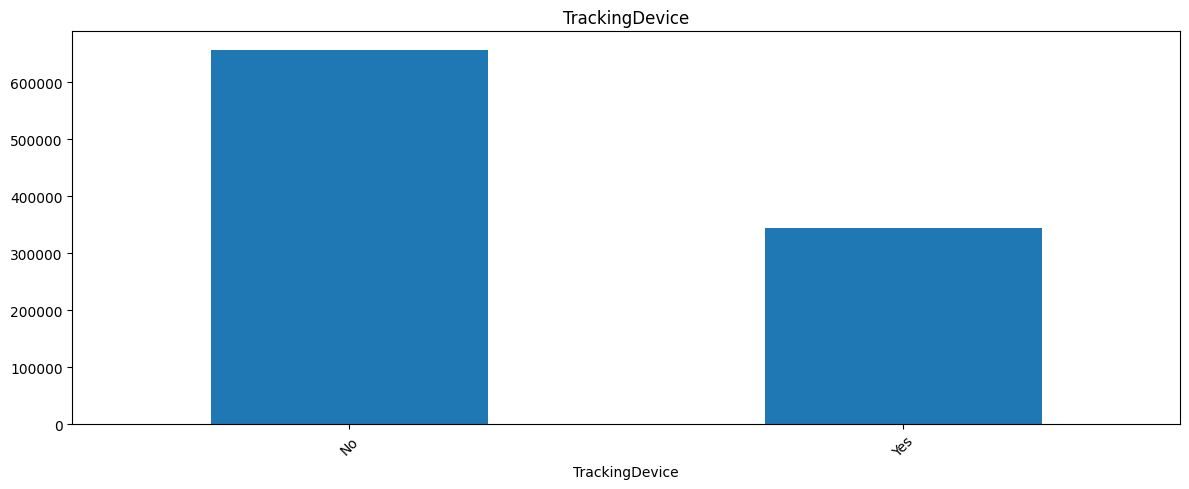

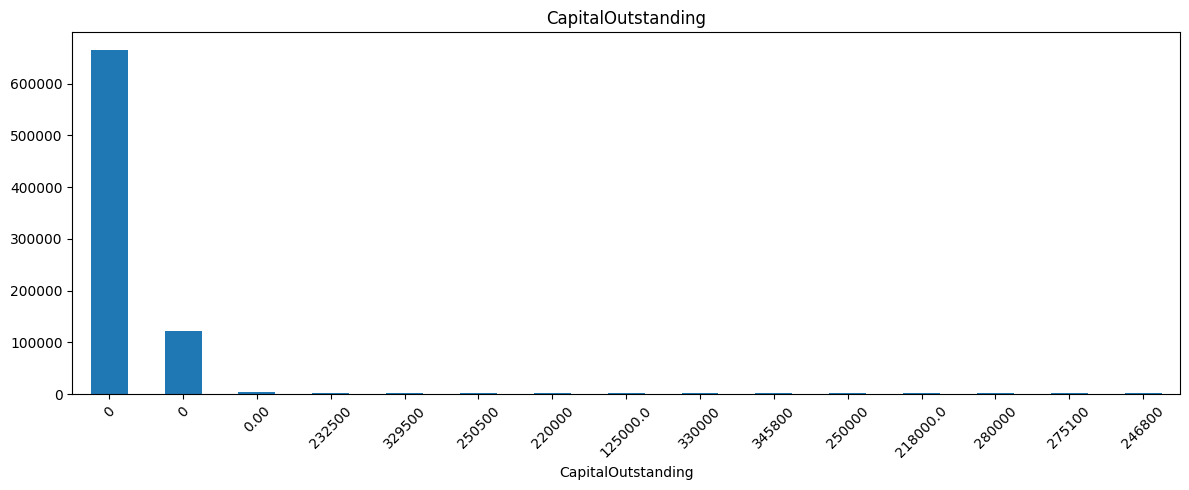

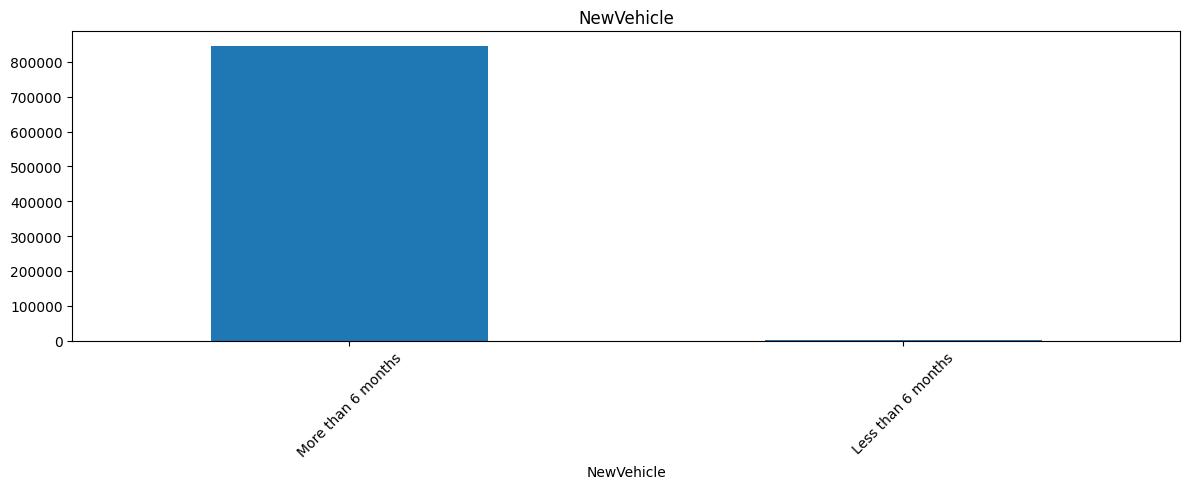

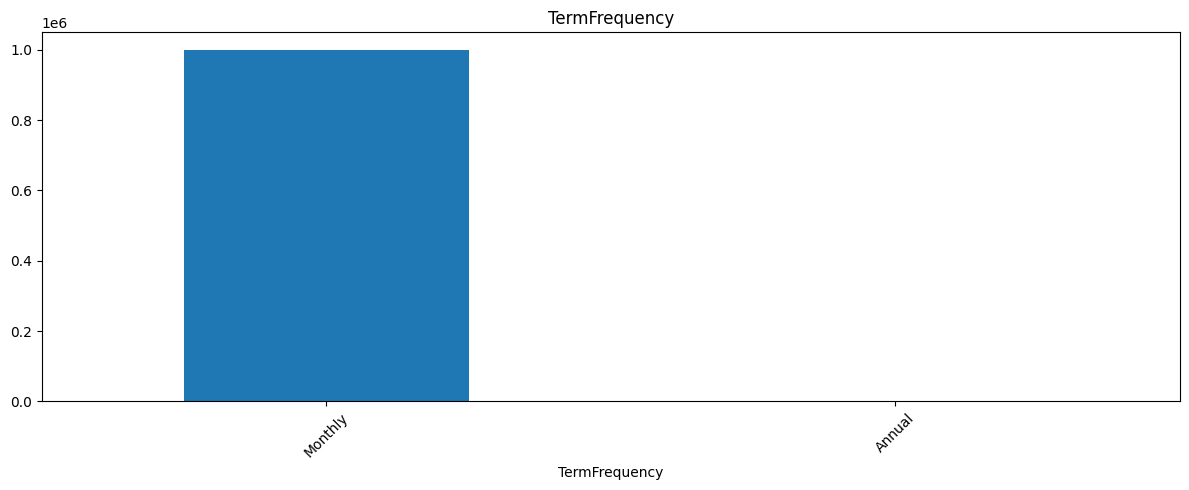

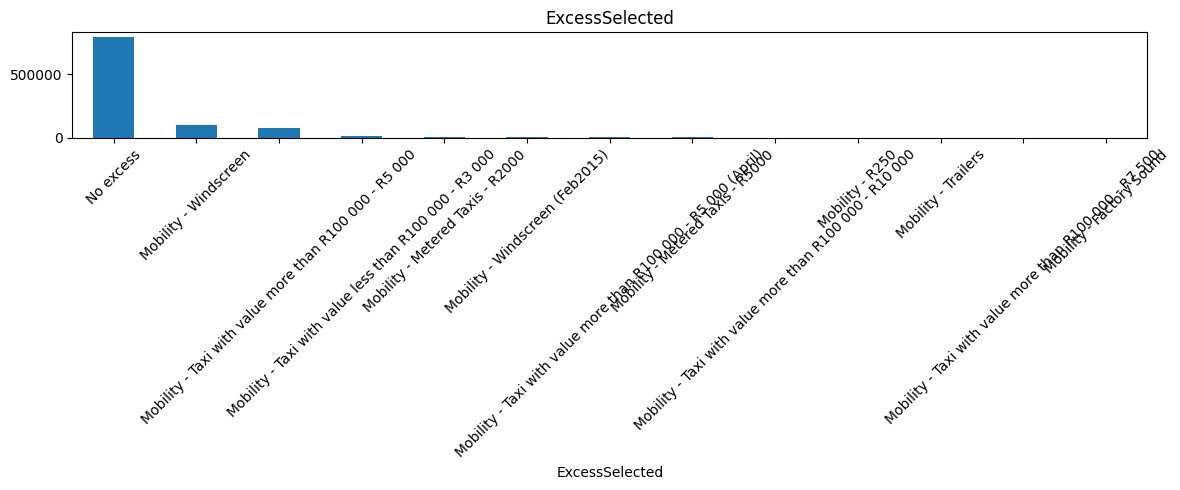

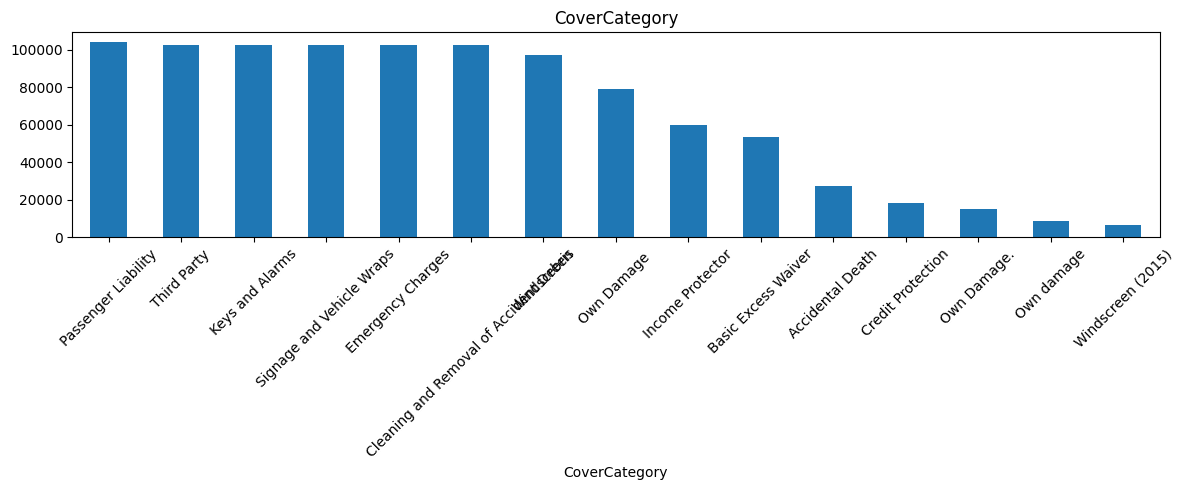

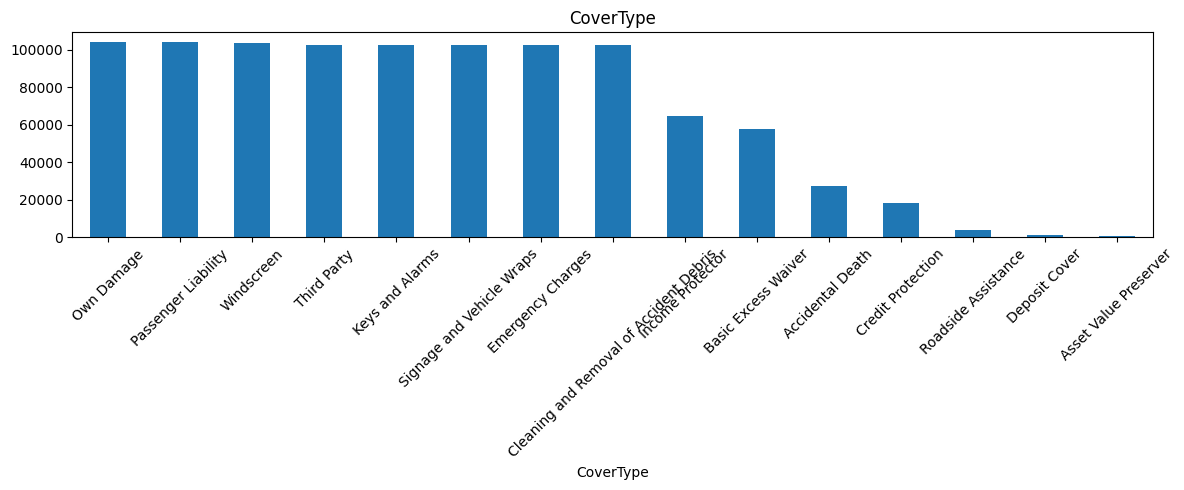

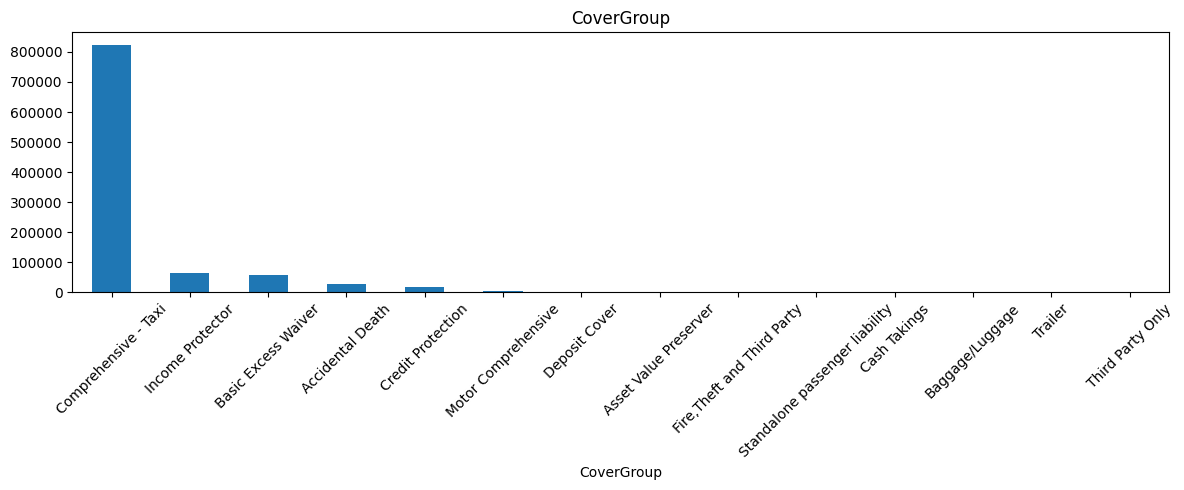

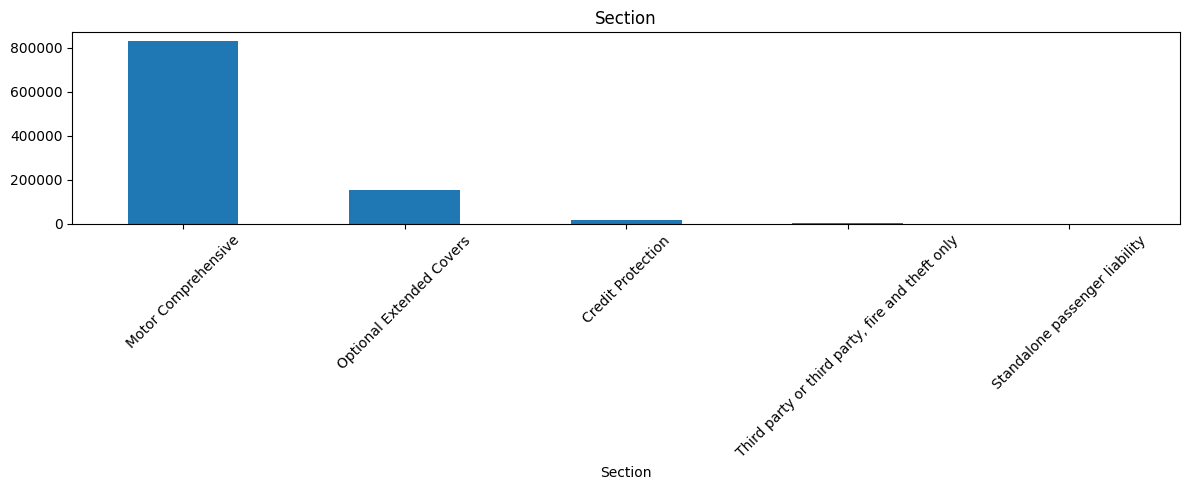

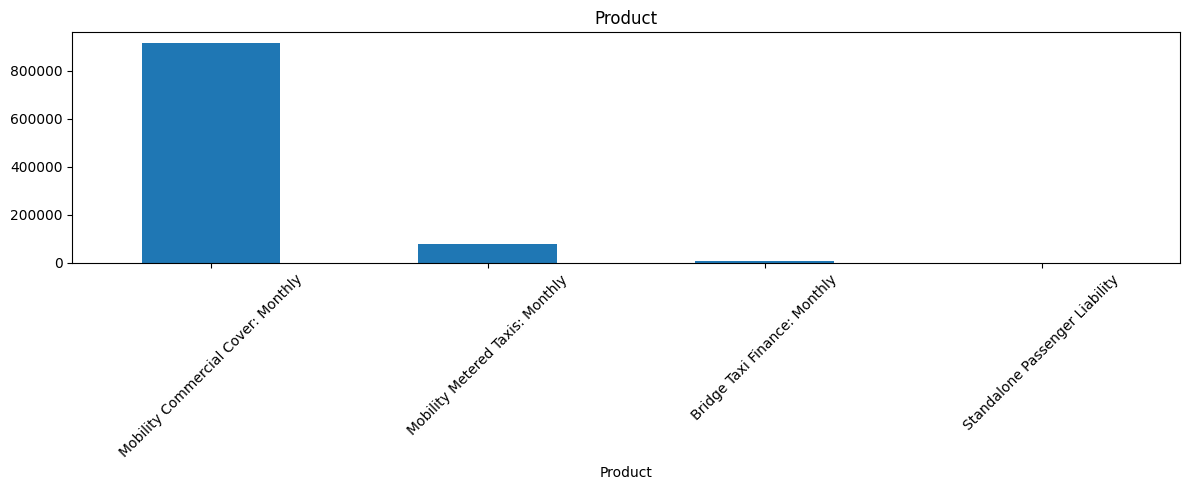

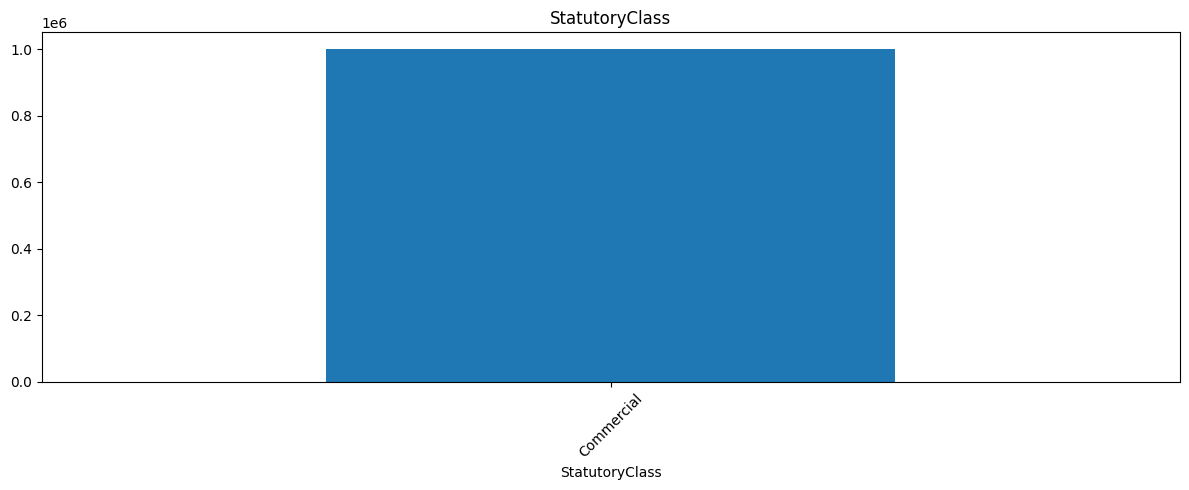

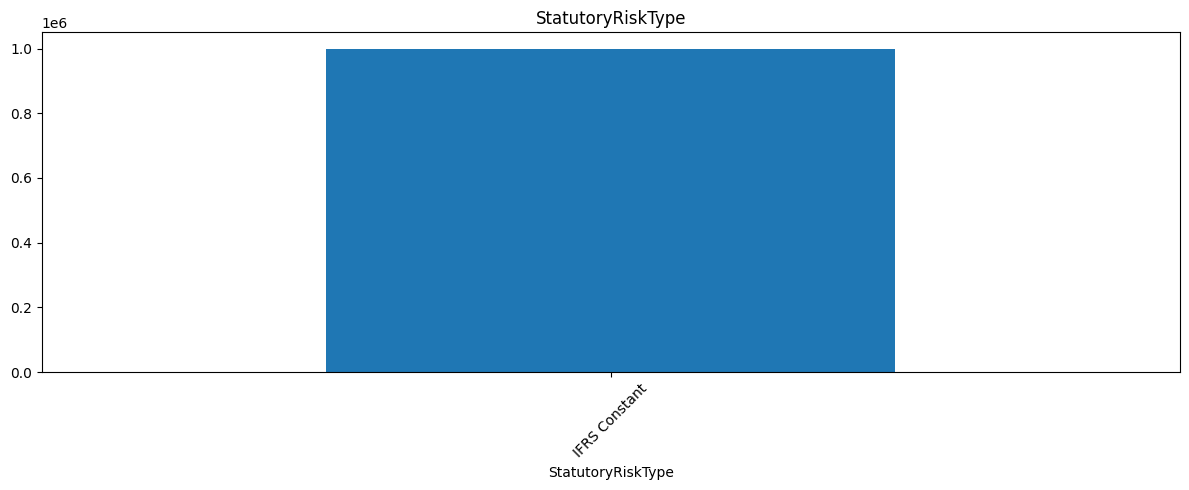

In [9]:
cols = get_categorical_columns(df)
plot_categorical_cols(df,cols)

<Figure size 1200x500 with 0 Axes>

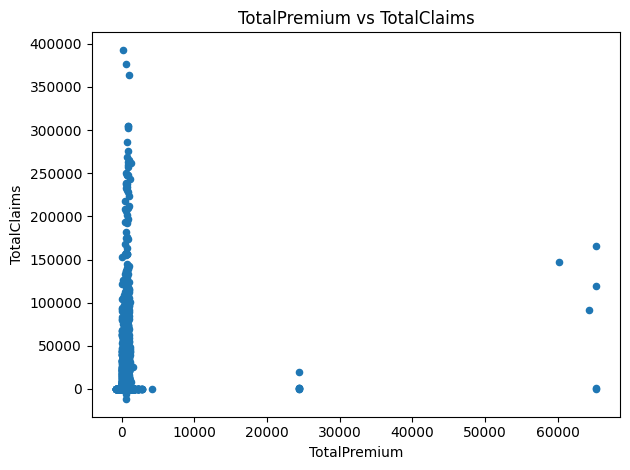

In [10]:
bivariate_scatter_plot(df, "TotalPremium", "TotalClaims")

c:\KAIM_projects\insurance-risk-analytics\src\eda_utils.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\KAIM_projects\insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


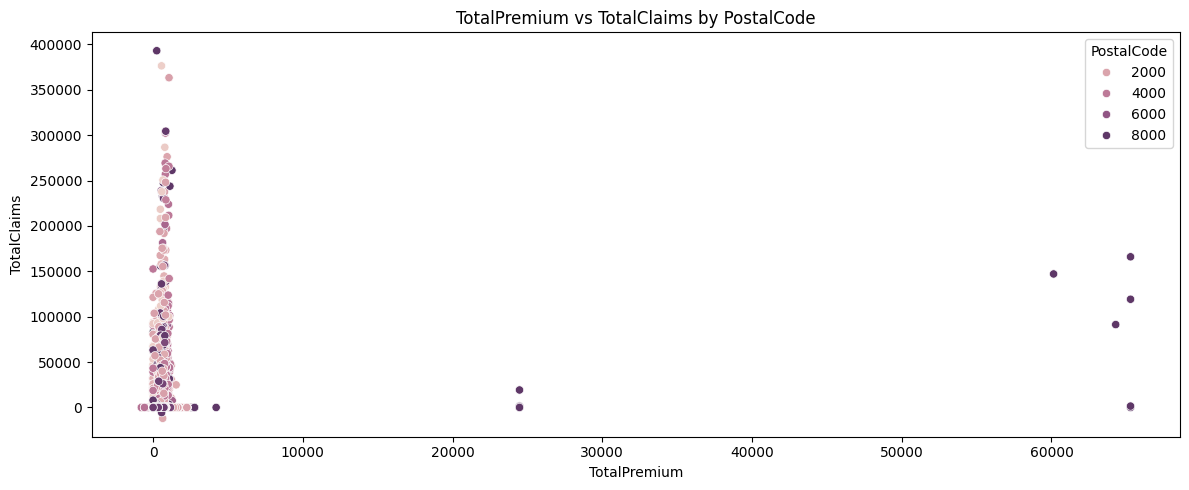

In [11]:
multivariate_scatter_plot(df, "TotalPremium", "TotalClaims", "PostalCode")

In [12]:
numeric_cols = get_numeric_columns
corr_mat = correlation_matrix(df, numeric_cols)
corr_mat

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
UnderwrittenCoverID,1.000000,0.916324,-0.018206,0.083310,0.065886,-0.026910,0.084892,-0.038613,-0.023781,0.003022,0.028029,0.065413,0.003011
PolicyID,0.916324,1.000000,-0.034186,0.074428,0.067192,-0.028551,0.088083,-0.032198,-0.031438,0.002141,0.025191,0.059572,0.002941
PostalCode,-0.018206,-0.034186,1.000000,0.100995,0.009472,-0.042656,-0.139570,-0.195637,0.083857,0.001549,0.016138,0.007394,0.000412
mmcode,0.083310,0.074428,0.100995,1.000000,-0.088748,-0.100871,0.196766,0.033500,0.021488,-0.010734,-0.003154,0.012419,-0.000615
RegistrationYear,0.065886,0.067192,0.009472,-0.088748,1.000000,-0.034001,0.096951,0.176013,0.068109,0.003872,0.065814,0.058666,0.005197
Cylinders,-0.026910,-0.028551,-0.042656,-0.100871,-0.034001,1.000000,0.301620,0.325936,-0.259174,0.001635,0.017942,0.006826,0.000043
cubiccapacity,0.084892,0.088083,-0.139570,0.196766,0.096951,0.301620,1.000000,0.566559,-0.298624,-0.002233,0.038396,0.042554,0.001228
kilowatts,-0.038613,-0.032198,-0.195637,0.033500,0.176013,0.325936,0.566559,1.000000,-0.115124,-0.002167,0.039054,0.035024,0.003099
NumberOfDoors,-0.023781,-0.031438,0.083857,0.021488,0.068109,-0.259174,-0.298624,-0.115124,1.000000,-0.000277,-0.006545,-0.008002,0.001700
SumInsured,0.003022,0.002141,0.001549,-0.010734,0.003872,0.001635,-0.002233,-0.002167,-0.000277,1.000000,-0.032294,-0.041174,-0.005129


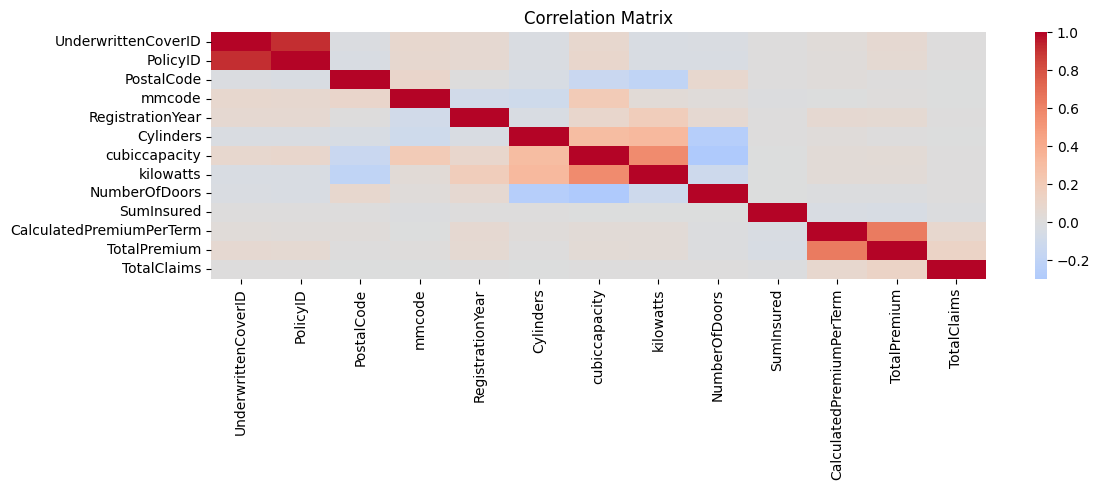

In [13]:
correlation_heatmap(corr_mat)

In [14]:
comp_table = comparison(df,"CoverType","Province")
comp_table

Province,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape
CoverType,,,,,,,,,
Accidental Death,1693,527,5050,8871,1084,706,4922,350,4118
Asset Value Preserver,10,0,449,74,0,53,144,2,133
Baggage/Luggage,34,0,103,0,0,12,12,0,11
Basic Excess Waiver,2226,546,26868,6969,1423,1235,6155,567,11780
Cash Takings,0,0,23,3,0,0,71,0,194
Cleaning and Removal of Accident Debris,3006,787,39517,17741,2494,5601,14546,599,18123
Credit Protection,467,109,8030,2510,514,1154,3427,95,1764
Deposit Cover,73,13,257,412,7,47,155,33,302
Emergency Charges,3006,787,39519,17741,2494,5601,14546,599,18123


<Figure size 1200x500 with 0 Axes>

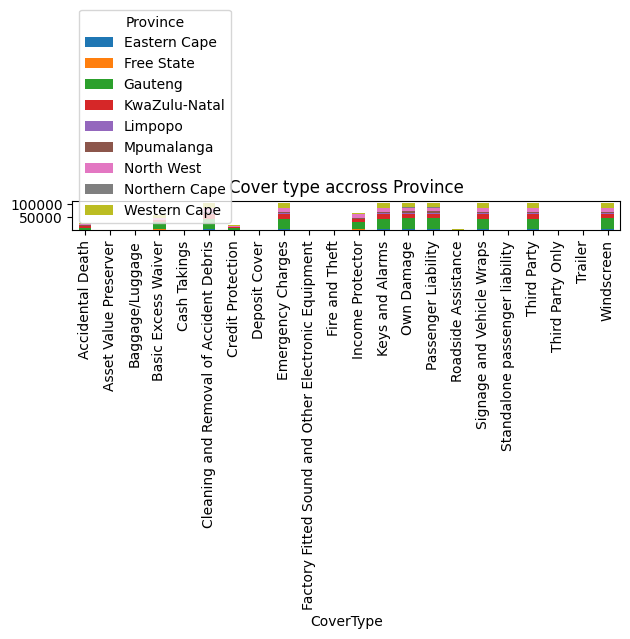

In [15]:
comparison_plot(comp_table, "Cover type", "Province")

In [16]:
avg_comp = avg_comparison(df,"Province","TotalPremium")
avg_comp

Province
KwaZulu-Natal    77.800695
Eastern Cape     70.546672
Free State       64.373780
Limpopo          61.899038
Gauteng          61.071115
Western Cape     57.416793
Mpumalanga       53.801205
North West       52.276258
Northern Cape    49.617253
Name: TotalPremium, dtype: float64

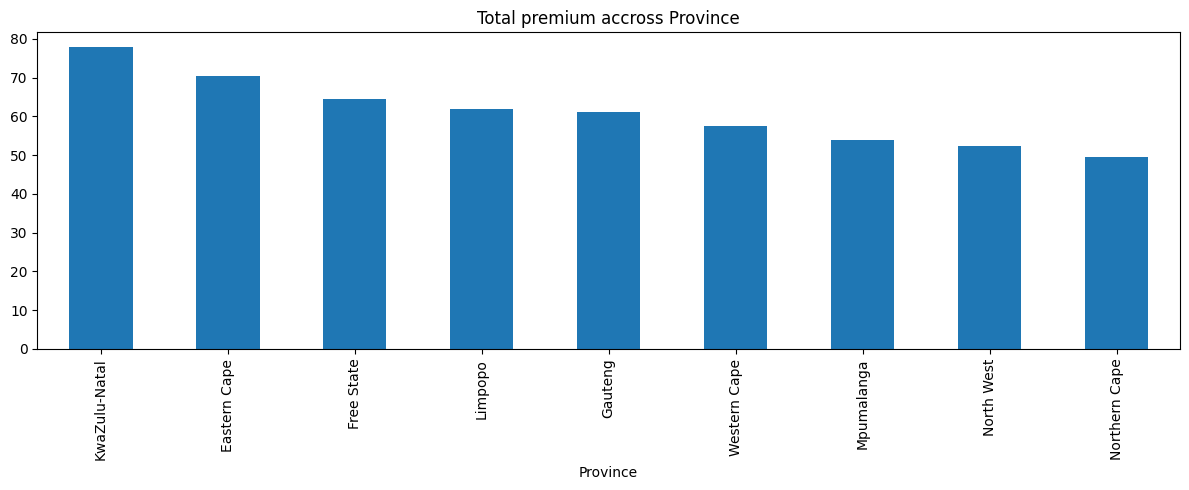

In [17]:
comparison_plot(avg_comp,"Total premium","Province")

In [18]:
comp_table = comparison(df,"Province","VehicleType")
comp_table

VehicleType,Bus,Heavy Commercial,Light Commercial,Medium Commercial,Passenger Vehicle
Province,,,,,
Eastern Cape,0,1,72,841,29422
Free State,0,46,154,349,7550
Gauteng,100,1410,1108,18836,372171
KwaZulu-Natal,80,101,432,7953,161215
Limpopo,0,220,316,4362,19938
Mpumalanga,324,496,687,4895,46236
North West,110,2100,99,9755,131223
Northern Cape,0,121,0,196,6063
Western Cape,51,2906,1029,6798,159780


<Figure size 1200x500 with 0 Axes>

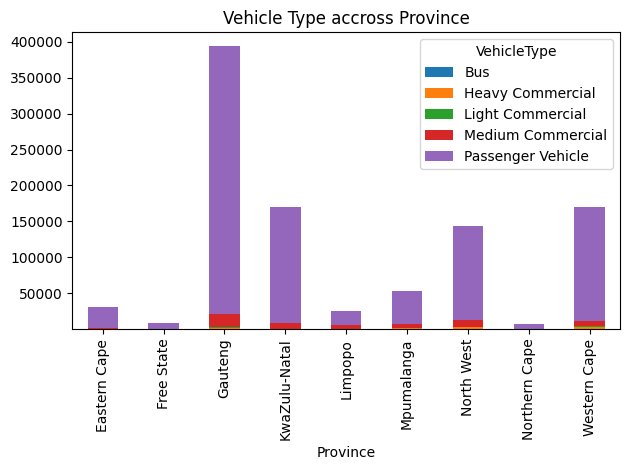

In [19]:
comparison_plot(comp_table, "Vehicle Type", "Province")

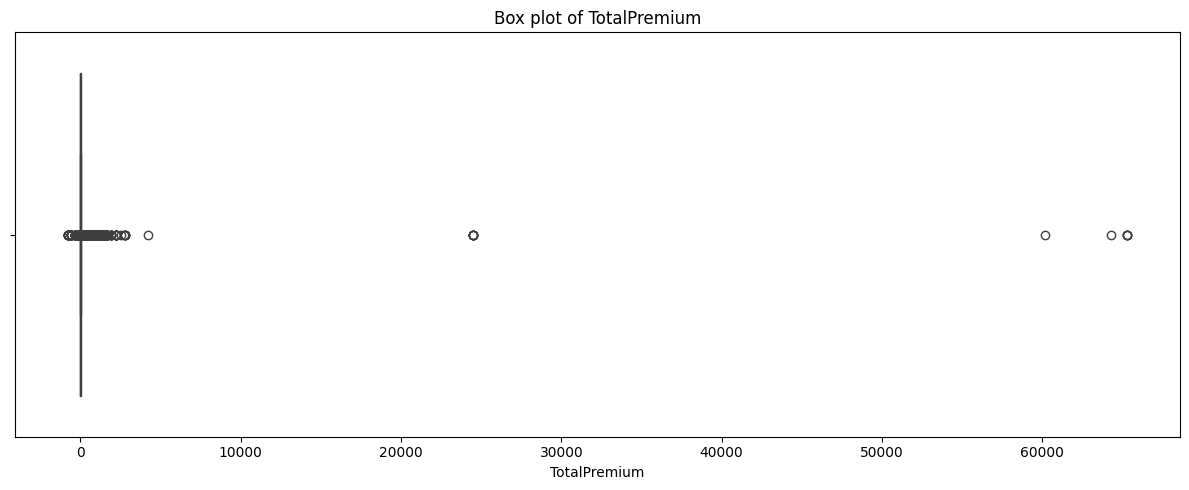

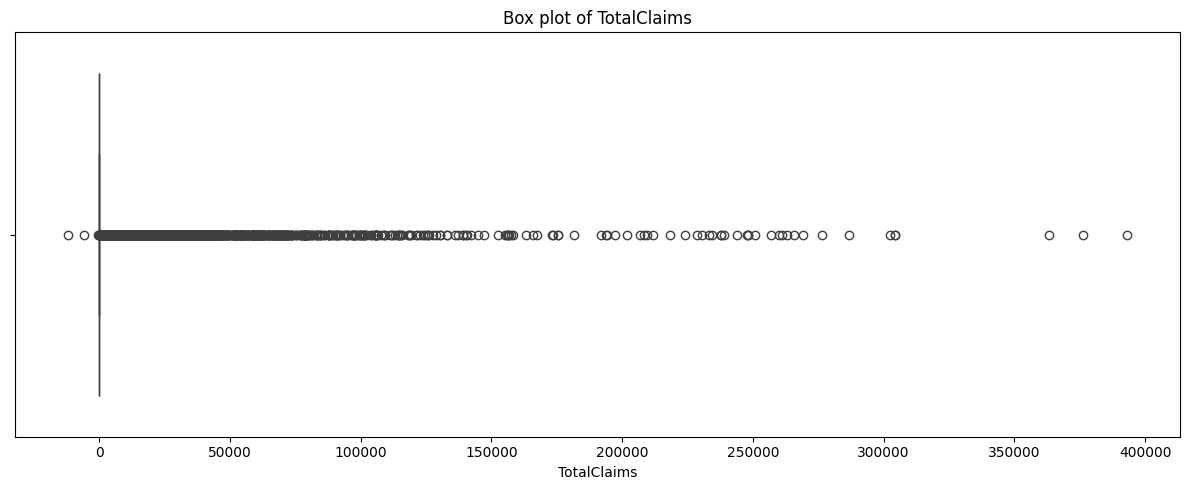

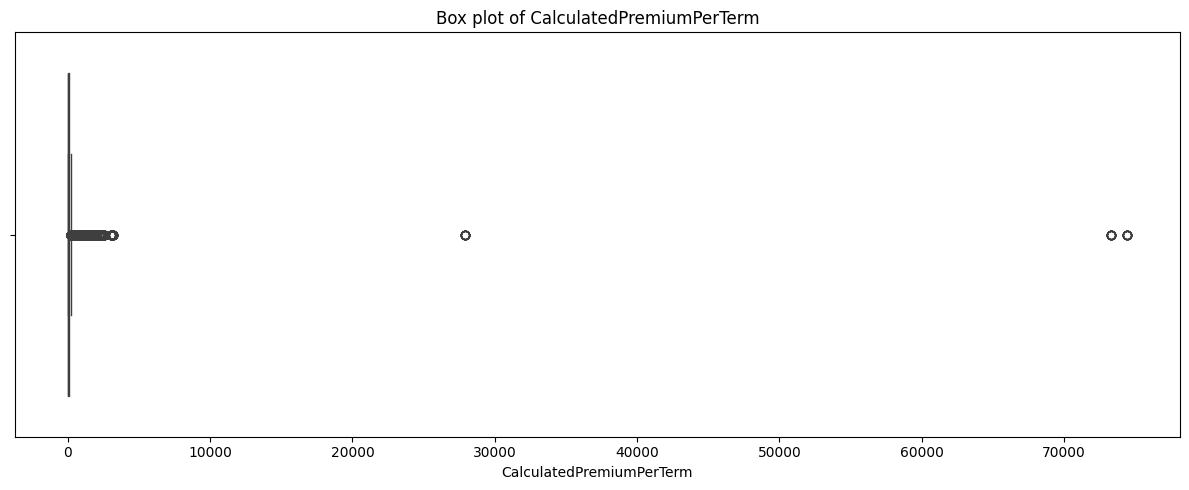

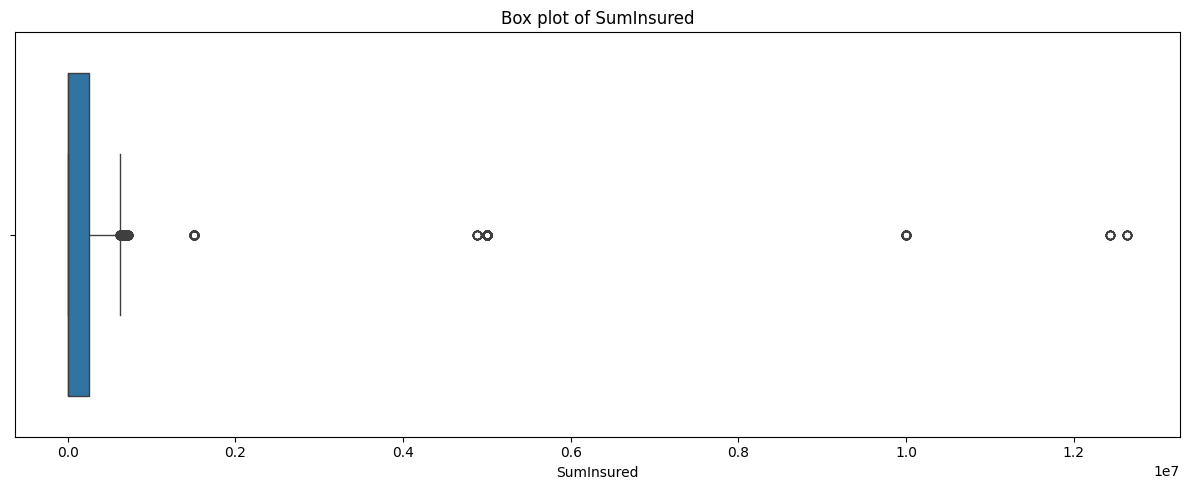

In [20]:
key_features = [
    "TotalPremium",
    "TotalClaims",
    "CalculatedPremiumPerTerm",
    "SumInsured",
]

box_plots(df,key_features)

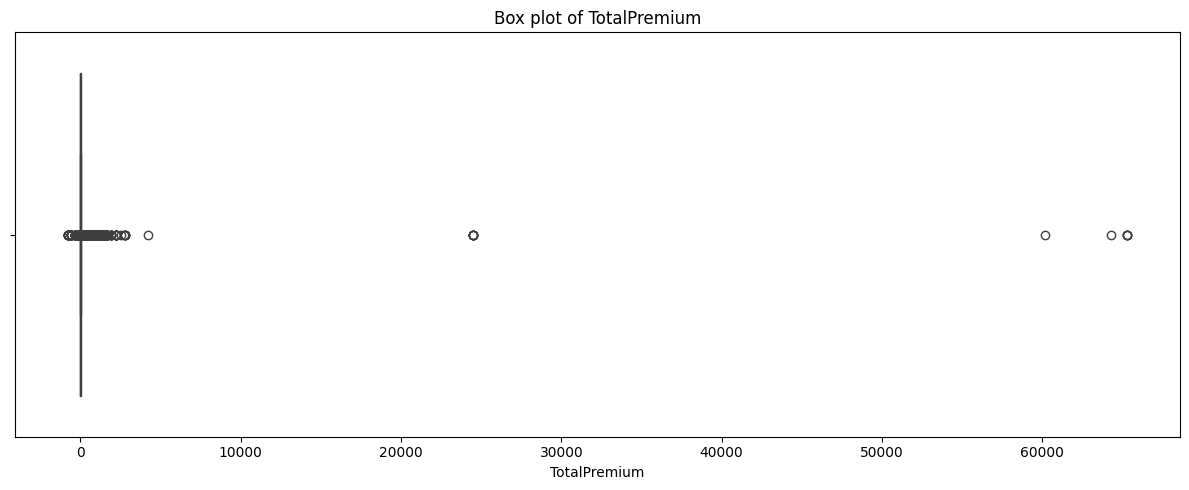

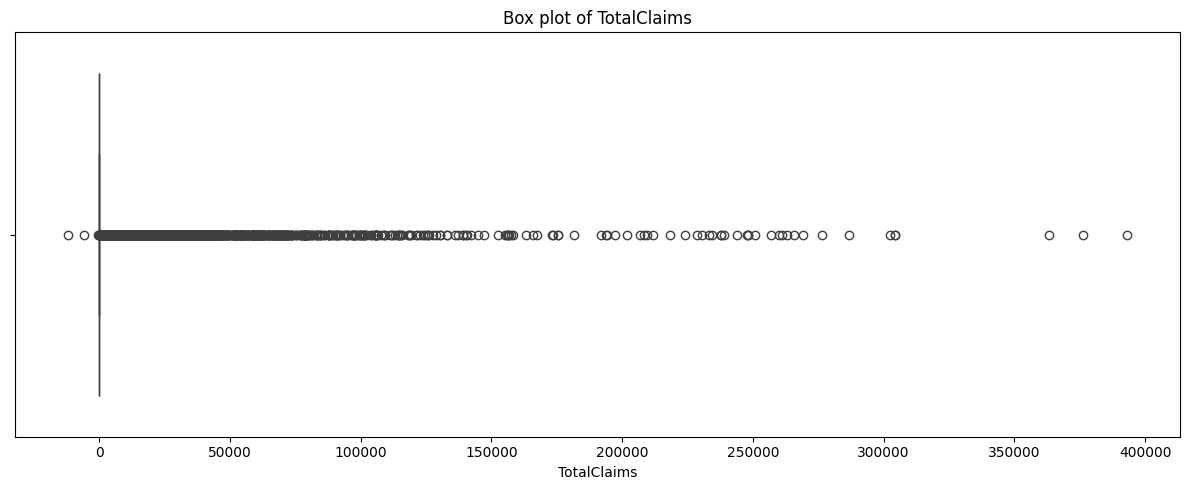

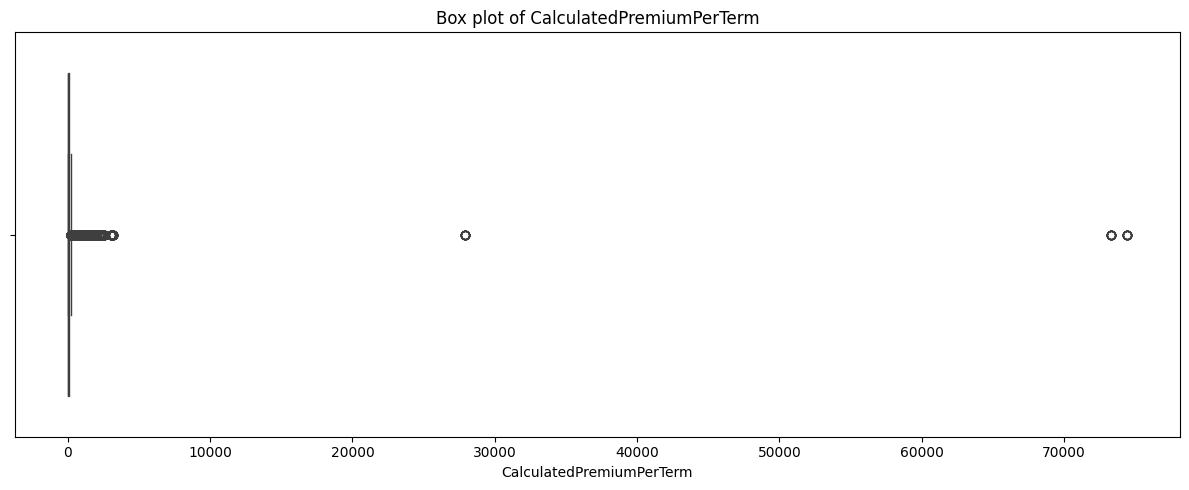

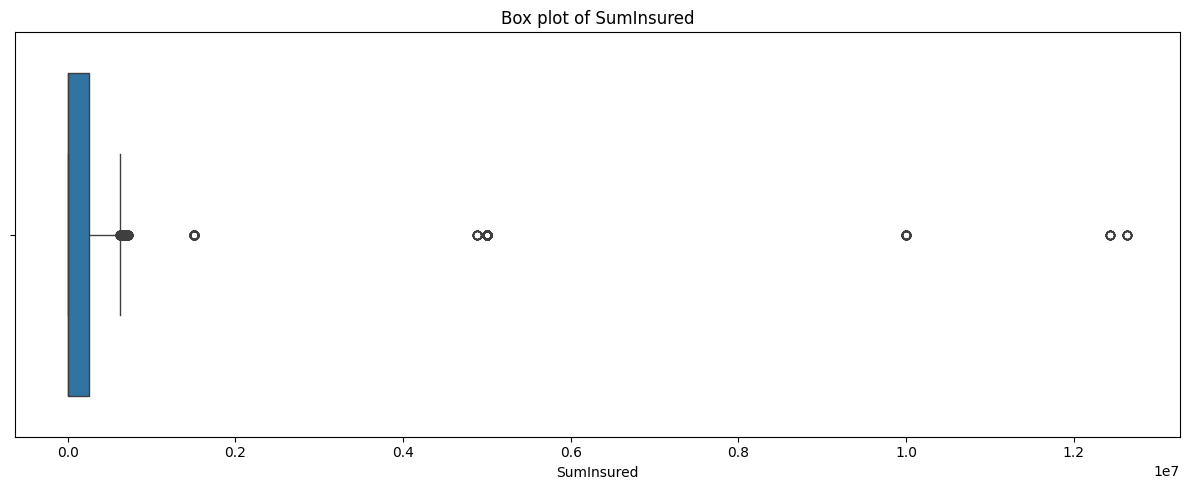

In [21]:
key_features = [
    "TotalPremium",
    "TotalClaims",
    "CalculatedPremiumPerTerm",
    "SumInsured"
]

box_plots(
    df,
    key_features
)

# Guiding Question 1

## What is the Overall Loss Ratio for the Portfolio?

The loss ratio is a key insurance performance metric calculated as:

Loss Ratio = Total Claims / Total Premium

A higher loss ratio indicates a larger proportion of premium revenue is being paid out as claims, while a lower loss ratio suggests greater portfolio profitability.

The analysis below evaluates the overall loss ratio and examines variations across provinces, vehicle types, and gender groups.

In [22]:
overall_loss_ratio(df)


np.float64(1.0477452570332206)

## Loss Ratio by Province

This analysis compares portfolio profitability across provinces.

Regional differences in loss ratios may indicate differences in risk exposure, driving conditions, customer behavior, or claim frequency.

In [23]:
province_loss_ratio(df)


,TotalClaims,TotalPremium,LossRatio
Province,,,
Gauteng,2.939415e+07,2.405377e+07,1.222018
KwaZulu-Natal,1.430138e+07,1.320908e+07,1.082693
Western Cape,1.038977e+07,9.806559e+06,1.059472
North West,5.920250e+06,7.490508e+06,0.790367
Mpumalanga,2.044675e+06,2.836292e+06,0.720897
Free State,3.549223e+05,5.213632e+05,0.680758
Limpopo,1.016477e+06,1.537324e+06,0.661199
Eastern Cape,1.356427e+06,2.140104e+06,0.633813
Northern Cape,8.949051e+04,3.165581e+05,0.282699


## Loss Ratio by Vehicle Type

Different vehicle categories may exhibit different risk profiles.

This section examines whether certain vehicle types are associated with higher or lower loss ratios.

In [24]:
vehicle_loss_ratio(df)


,TotalClaims,TotalPremium,LossRatio
VehicleType,,,
Heavy Commercial,7.504746e+05,4.609479e+05,1.628112
Medium Commercial,4.119867e+06,3.922746e+06,1.050251
Passenger Vehicle,5.937207e+07,5.664202e+07,1.048198
Light Commercial,6.045250e+04,2.604975e+05,0.232066
Bus,7.996535e+03,5.824474e+04,0.137292


## Loss Ratio by Gender

This analysis compares loss ratios across gender groups.

The objective is to identify whether significant differences exist in claims experience and portfolio profitability.

In [25]:
gender_loss_ratio(df)


,TotalClaims,TotalPremium,LossRatio
Gender,,,
Female,2.502461e+05,3.044806e+05,0.821879
Male,1.396704e+06,1.580143e+06,0.883910
Not specified,6.271410e+07,5.920275e+07,1.059311


# Guiding Question 2

## Distribution of Financial Variables

Key financial variables such as premiums, claims, and insured values are analyzed to understand their distributions.

Special attention is given to skewness, concentration of observations, and the presence of extreme values that may influence analytical results.

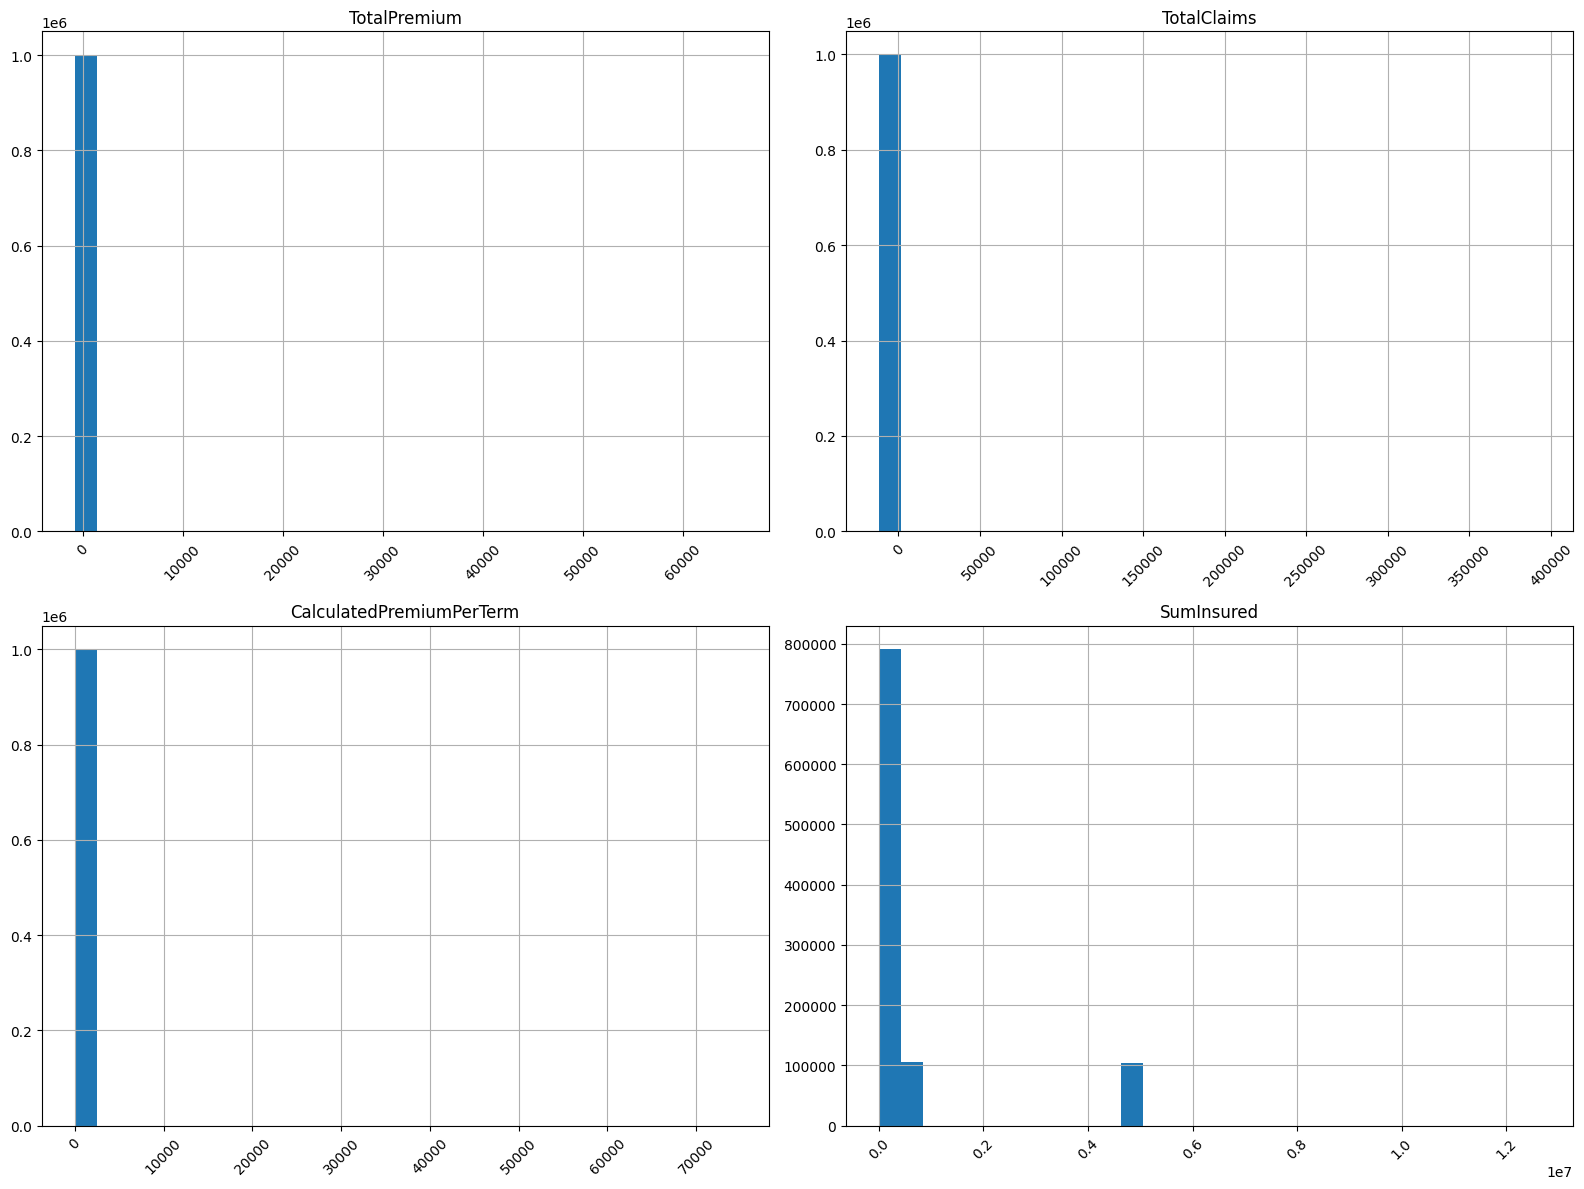

In [26]:
financial_cols = [
    "TotalPremium",
    "TotalClaims",
    "CalculatedPremiumPerTerm",
    "SumInsured"
]

plot_histograms(
    df,
    financial_cols
)

## Observations

The distributions indicate that most policies are concentrated within lower value ranges, while a relatively small number of observations exhibit substantially larger values.

This pattern is common in insurance datasets and reflects the presence of high-severity but low-frequency events.

# Guiding Question 3

## Temporal Trends

This section examines how premiums and claims evolve over time.

Monthly trends are analyzed to identify potential changes in claim frequency, claim severity, and portfolio performance throughout the observation period.

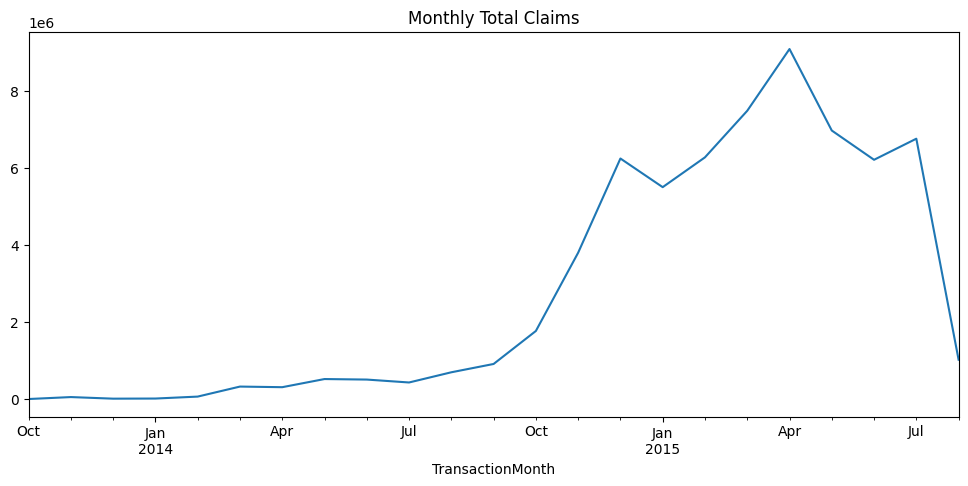

In [27]:
monthly_claims = (
    df.groupby("TransactionMonth")
    ["TotalClaims"]
    .sum()
)

monthly_claims.plot(
    figsize=(12, 5),
    title="Monthly Total Claims"
)

plt.show()

## Monthly Claims Trend

Monthly claim totals provide insight into changes in portfolio risk over time.

Periods of increased claim activity may indicate seasonal effects or shifts in underlying risk factors.

## Monthly Premium Trend

Monthly premium totals are analyzed to assess changes in portfolio growth and revenue generation over the study period.

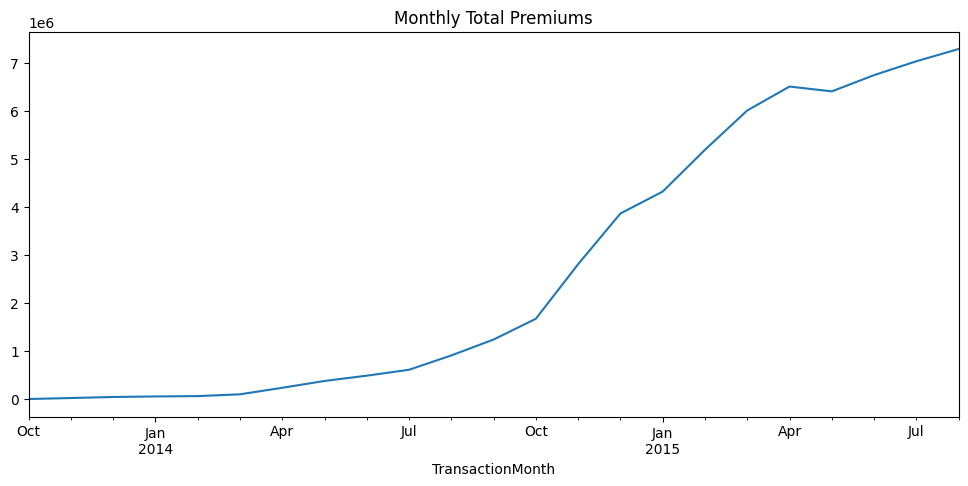

In [28]:
monthly_premiums = (
    df.groupby("TransactionMonth")
    ["TotalPremium"]
    .sum()
)

monthly_premiums.plot(
    figsize=(12, 5),
    title="Monthly Total Premiums"
)
plt.show()

# Guiding Question 4

## Vehicle Makes and Models Associated with Claims

Vehicle make and model can influence both claim frequency and claim severity.

This section identifies vehicle makes and models associated with the highest and lowest average claim amounts.

## Vehicle Makes with Lowest Average Claims

The following results identify vehicle makes that exhibit relatively low average claim amounts.

These vehicles may represent lower-risk segments within the portfolio.

In [33]:
make_claims = (
    df.groupby("make")
    ["TotalClaims"]
    .mean()
    .sort_values()
)

make_claims.head(10)

make
CITROEN                                0.0
CHERY                                  0.0
FORD                                   0.0
DAIHATSU                               0.0
GEELY                                  0.0
HINO                                   0.0
HUMMER                                 0.0
HONDA                                  0.0
JINBEI                                 0.0
KIA                                    0.0
Name: TotalClaims, dtype: float64

In [34]:
make_claims.tail(10)


make
IVECO                                   89.667017
BMW                                     90.558050
FIAT                                   108.625642
B.A.W                                  132.934016
POLARSUN                               134.044800
AUDI                                   137.843083
MARCOPOLO                              156.794806
HYUNDAI                                174.215195
JMC                                    191.684795
SUZUKI                                 419.634546
Name: TotalClaims, dtype: float64

## Vehicle Makes with Highest Average Claims

The following results identify vehicle makes associated with relatively high average claim amounts.

These vehicles may require additional consideration in future pricing strategies.

In [31]:
model_claims = (
    df.groupby("Model")
    ["TotalClaims"]
    .mean()
    .sort_values()
)

model_claims.head(10)

Model
C200K CLASSIC A/T           -0.250832
VENTURE 2400D 6+4 New        0.000000
50C15V15 F/C P/V             0.000000
0305 M BAR B/S CCL           0.000000
YARIS ZEN3 ACS               0.000000
YARIS ZEN3                   0.000000
YARIS 1.3 5Dr                0.000000
ACCENT 1.5 CSi               0.000000
A5 SPRTBACK 2.0 TDI MULTI    0.000000
A4 3.0 TDI QUATTRO (B7)      0.000000
Name: TotalClaims, dtype: float64

## Vehicle Models with Lowest Average Claims

This analysis identifies individual vehicle models that generate relatively low average claims.

In [32]:
model_claims.tail(10)

Model
POLO 1.6 COMFORTLINE            431.842105
A4 1.8T S AVANT MULTITRONIC     480.282859
YARIS T1 3Dr                    618.719846
ERTIGA 1.4 GA                   631.774519
SPRINTER 312D F/C P/V           664.540138
C180 BE COUPE                   743.459027
POLO VIVO 1.6 5Dr               827.558882
DUCATO 2.3 JTD VETRATO         1014.681021
H-1 2.5 CRDI WAGON A/T         4118.181043
L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
Name: TotalClaims, dtype: float64